1. Не приведен анализ change-points. Нужно дописать.
Найдено 9 точек смены тренда (1968, 1971, 1973, 1975, 1979, 1981, 1982, 1985, 1987). Они соответствуют ключевым макроэкономическим событиям: нефтяные кризисы 1973 и 1979, политика ФРС по борьбе с инфляцией в начале 1980-х (ставки достигли 16%), "Черный понедельник" 1987 г. Это подтверждает нестационарность данных и необходимость использования моделей с переменной волатильностью (CKLS).
3.  Почему AIC, BIC > 0
AIC = 2k - 2logLik и BIC = k·ln(n) - 2logLik, где logLik — логарифм правдоподобия. В коде функция nll() возвращает отрицательное логарифмическое правдоподобие, поэтому logLik < 0. При подстановке: AIC = 2k - 2·(-|logLik|) = 2k + 2|logLik| > 0. Положительные значения AIC/BIC нормальны. Важно их относительное сравнение для выбора модели, а не абсолютная величина.
4. Резкий рост own CKLS на правой границе
Резкий рост конце 1980-х объясняется двумя причинами. Первое это накопление ошибок дискретизации: при симуляции на 300+ шагах малые ошибки в оценке параметров (особенно γ=1.44 в диффузии σ·X^γ) экспоненциально нарастают. Второе - особенность CKLS: при γ > 1 волатильность растет быстрее уровня ставки, что создает положительную обратную связь — высокие ставки → высокая волатильность → еще более высокие ставки. В реальности этот эффект ограничивается политикой ФРС, но в модели такого ограничения нет.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import shapiro
import warnings, logging, sys, io
warnings.filterwarnings('ignore')
logging.getLogger('pymle').setLevel(logging.ERROR)

Outliers: 32/306 (10.5%)
Mean: 0.0104  Var: 0.5744
Shapiro p-value: 1.92e-15
Detected change points: 9


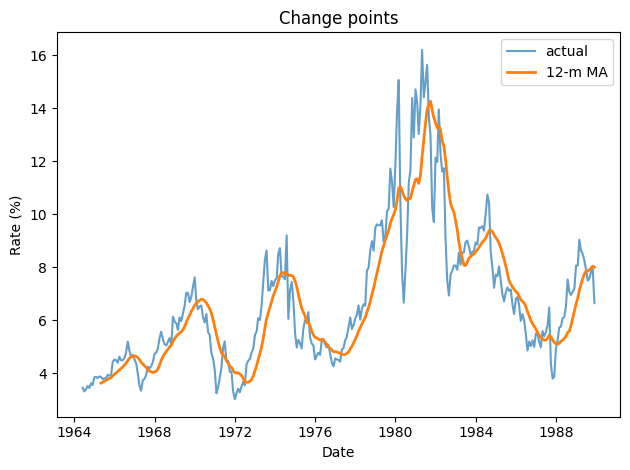

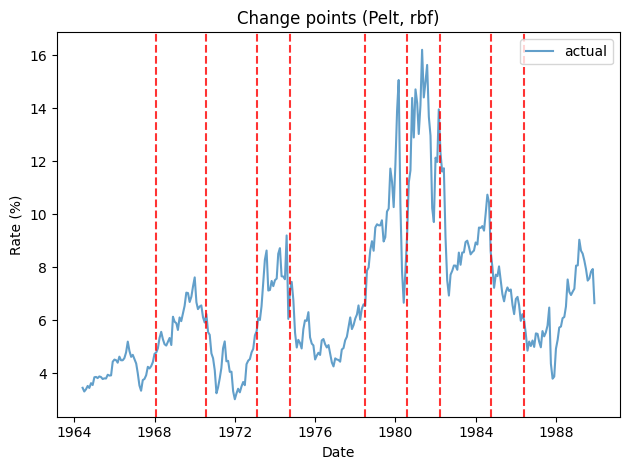

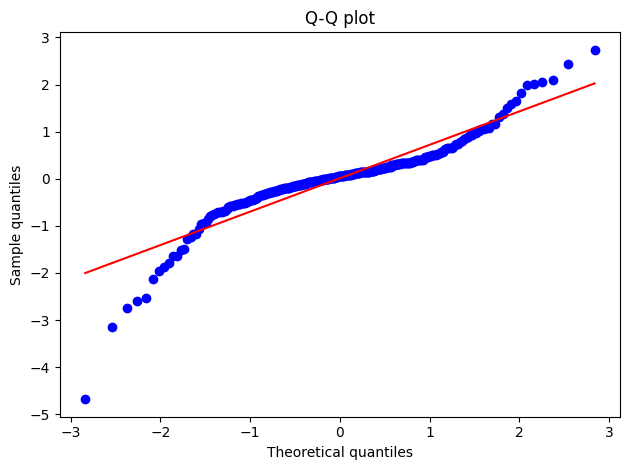

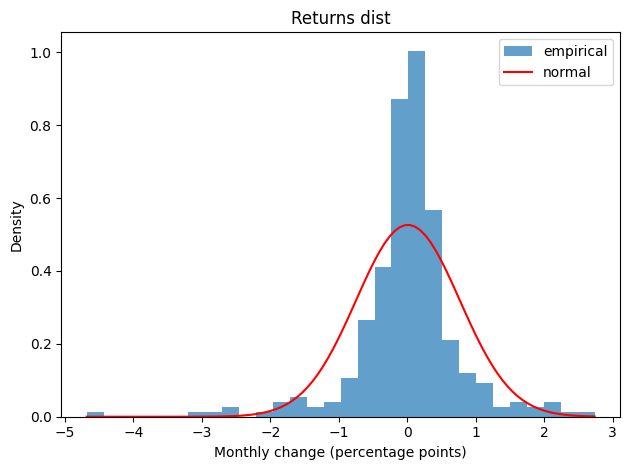

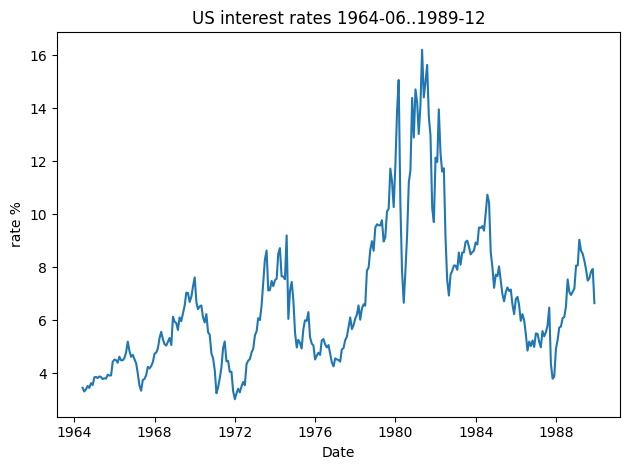

In [18]:
df = pd.read_excel('data/Project_3.xlsx', index_col=0)
vals, dts = [], []
for yr in df.index:
    for m in range(1, 13):
        if pd.notna(df.loc[yr, df.columns[m-1]]):
            dts.append(pd.Timestamp(year=yr, month=m, day=1))
            vals.append(float(df.loc[yr, df.columns[m-1]]))
Xall = np.array(vals)
dt_all = pd.to_datetime(dts)
mask = (dt_all >= '1964-06-01') & (dt_all <= '1989-12-01')
X = Xall[mask]
t = dt_all[mask]
T = len(X)

dt = 1/12
dx = np.diff(X)
Q1,Q3=np.percentile(dx,[25,75])
IQR=Q3-Q1
out=dx[(dx<Q1-1.5*IQR)|(dx>Q3+1.5*IQR)]
print(f'Outliers: {len(out)}/{len(dx)} ({100*len(out)/len(dx):.1f}%)')
print(f'Mean: {np.mean(dx):.4f}  Var: {np.var(dx):.4f}')
print(f'Shapiro p-value: {shapiro(dx).pvalue:.2e}')

w=12
rm=pd.Series(X).rolling(w).mean()
plt.figure()
plt.plot(t,X,label='actual',alpha=0.7)
plt.plot(t,rm,label=f'{w}-m MA',lw=2)
plt.title('Change points')
plt.xlabel('Date')                
plt.ylabel('Rate (%)')             
plt.legend()
plt.tight_layout()
import ruptures as rpt

# поиск точек смены среднего уровня
algo = rpt.Pelt(model="rbf").fit(X)
result = algo.predict(pen=3)
cp_idx = [idx-1 for idx in result if idx < T]   # последний индекс сегмента

plt.figure()
plt.plot(t, X, label='actual', alpha=0.7)
for cp in cp_idx[:-1]:          # последний элемент – конец выборки
    plt.axvline(x=t[cp], color='red', linestyle='--', alpha=0.8)
plt.title('Change points (Pelt, rbf)')
plt.xlabel('Date')             
plt.ylabel('Rate (%)')         
plt.legend()
plt.tight_layout()
print(f'Detected change points: {len(cp_idx)-1}')



from scipy import stats
plt.figure()
stats.probplot(dx,dist="norm",plot=plt)
plt.title('Q-Q plot')
plt.xlabel('Theoretical quantiles')   
plt.ylabel('Sample quantiles')        
plt.tight_layout()

plt.figure()
plt.hist(dx,bins=30,density=True,alpha=0.7,label='empirical')
xn=np.linspace(dx.min(),dx.max(),100)
plt.plot(xn,stats.norm.pdf(xn,np.mean(dx),np.std(dx)),'r-',label='normal')
plt.title('Returns dist')
plt.xlabel('Monthly change (percentage points)')   
plt.ylabel('Density')                             
plt.legend()
plt.tight_layout()
plt.figure()
plt.plot(t, X)
plt.title('US interest rates 1964-06..1989-12')
plt.xlabel('Date')               
plt.ylabel('rate %')             
plt.tight_layout()

In [19]:
def em(x,b,p,dt): 
    return x + b(x,p)*dt
def ev(x,s,p,dt): 
    return s(x,p)**2*dt
def km(x,b,s,p,dt,h=1e-4):
    b0=b(x,p)
    s2=s(x,p)**2
    bp=(b(x+h,p)-b(x-h,p))/(2*h)
    bpp=(b(x+h,p)-2*b0+b(x-h,p))/(h*h)
    return x + b0*dt + 0.5*(b0*bp+0.5*s2*bpp)*dt*dt
def kv(x,b,s,p,dt,h=1e-4):
    b0=b(x,p)
    s2=s(x,p)**2
    bp=(b(x+h,p)-b(x-h,p))/(2*h)
    s2p=(s(x+h,p)**2-s(x-h,p)**2)/(2*h)
    s2pp=(s(x+h,p)**2-2*s2+s(x-h,p)**2)/(h*h)
    return s2*dt + (s2*bp+b0*s2p+0.5*s2*s2pp+s2p**2)*dt*dt/2
def som(x,b,s,p,dt,h=1e-4):
    b0=b(x,p)
    L=(b(x+h,p)-b(x-h,p))/(2*h)
    return x + b0*dt if abs(L)<1e-8 else x + b0*(np.exp(L*dt)-1)/L
def sov(x,b,s,p,dt,h=1e-4):
    s2=s(x,p)**2
    L=(b(x+h,p)-b(x-h,p))/(2*h)
    return s2*dt if abs(L)<1e-8 else s2*(np.exp(2*L*dt)-1)/(2*L)

def nll(p,b,s,method,X,dt):
    m=np.empty(len(X)-1)
    v=np.empty(len(X)-1)
    for i in range(1,len(X)):
        xp=X[i-1]
        if method=='euler':
            m[i-1]=em(xp,b,p,dt)
            v[i-1]=ev(xp,s,p,dt)
        elif method=='kessler':
            m[i-1]=km(xp,b,s,p,dt)
            v[i-1]=kv(xp,b,s,p,dt)
        elif method=='shoji_ozaki':
            m[i-1]=som(xp,b,s,p,dt)
            v[i-1]=sov(xp,b,s,p,dt)
    v=np.maximum(v,1e-12)
    return 0.5*np.sum(np.log(2*np.pi*v)+(X[1:]-m)**2/v)

In [20]:
models={
 'BM':(lambda x,p:p[0],lambda x,p:p[1],[0.0,1.0],[(None,None),(1e-6,None)],2),
 'OU':(lambda x,p:p[0]+p[1]*x,lambda x,p:p[2],[0.0,0.0,1.0],[(None,None),(None,None),(1e-6,None)],3),
 'CIR':(lambda x,p:p[0]+p[1]*x,lambda x,p:p[2]*np.sqrt(np.maximum(x,1e-10)),
        [2.0,-0.5,0.5],[(1e-6,None),(None,None),(1e-6,None)],3),
 'GBM':(lambda x,p:p[0]*x,lambda x,p:p[1]*x,[0.0,0.1],[(None,None),(1e-6,None)],2),
 'CEV':(lambda x,p:p[0]*x,lambda x,p:p[1]*x**p[2],[0.0,0.1,1.2],[(None,None),(1e-6,None),(0.1,3)],3),
 'CKLS':(lambda x,p:p[0]+p[1]*x,lambda x,p:p[2]*np.maximum(x,1e-10)**p[3],
         [2.1, -0.26, 0.13, 1.45],[(1e-6,None),(None,None),(1e-6,None),(0.1,3)],4),
#  'CKLS':(lambda x,p:p[0]+p[1]*x,lambda x,p:p[2]*np.maximum(x,1e-10)**p[3],
#          [2.0,-0.2,0.15,1.5],[(1e-6,None),(None,None),(1e-6,None),(0.1,3)],4)
}

methods=['euler','kessler','shoji_ozaki']
res_tab=[]
print('my estimates')
for method in methods:
    for name,(b,s,p0,bnds,k) in models.items():
        res=minimize(lambda p:nll(p,b,s,method,X,dt),p0,bounds=bnds,method='L-BFGS-B')
        loglik=-res.fun
        aic=2*k-2*loglik
        bic=k*np.log(T-1)-2*loglik
        res_tab.append((method,name,loglik,aic,bic,*res.x))
cols=['Method','Model','LogLik','AIC','BIC']+[f'p{i}' for i in range(4)]
tab_df=pd.DataFrame(res_tab,columns=cols[:5+4])
print(tab_df[['Method','Model','AIC','BIC']].to_string(index=False))

my estimates
     Method Model        AIC        BIC
      euler    BM 702.745612 710.192782
      euler    OU 697.687389 708.858144
      euler   CIR 583.454530 594.625286
      euler   GBM 517.366490 524.813660
      euler   CEV 500.389216 511.559971
      euler  CKLS 497.758265 512.652606
    kessler    BM 702.745612 710.192782
    kessler    OU 697.752819 708.923574
    kessler   CIR 585.347572 596.518327
    kessler   GBM 517.366621 524.813791
    kessler   CEV 500.317337 511.488092
    kessler  CKLS 497.524976 512.419316
shoji_ozaki    BM 702.745612 710.192782
shoji_ozaki    OU 697.687389 708.858144
shoji_ozaki   CIR 583.454530 594.625286
shoji_ozaki   GBM 517.366490 524.813660
shoji_ozaki   CEV 500.389216 511.559971
shoji_ozaki  CKLS 497.758114 512.652455


In [21]:
try:
    from pymle.models import CIR as cp, CKLS as ckp, CEV as cvp, OrnsteinUhlenbeck as oup
    from pymle.models.BrownianMotion import BrownianMotion
    from pymle.models.GeometricBM import GeometricBM
    from pymle.core.TransitionDensity import EulerDensity, KesslerDensity, ShojiOzakiDensity
    from pymle.fit.AnalyticalMLE import AnalyticalMLE

    pymle_models=[BrownianMotion,GeometricBM,cp,cvp,oup,ckp]
    pymle_names=['BM','GBM','CIR','CEV','OU','CKLS']
    densities=[EulerDensity,KesslerDensity,ShojiOzakiDensity]
    dnames=['euler','kessler','shoji_ozaki']

    pymle_res=[]
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    for Mdl,name in zip(pymle_models,pymle_names):
        if name=='CKLS':   
            guess=np.array([2.0,-0.26,0.13,1.44])
            bounds=[(0,10),(-10,10),(0.01,3),(0.1,2)]
        elif name=='CIR':  
            guess=np.array([2.0,-0.5,0.5])
            bounds=[(0,10),(0,4),(0.01,1)]
        elif name=='CEV':  
            guess=np.array([0.1,0.1,1.2])
            bounds=[(None,None),(0.01,None),(0.1,3)]
        elif name=='OU':   
            guess=np.array([1.0,-0.5,0.5])
            bounds=[(None,None),(None,None),(0.01,None)]
        elif name=='BM':   
            guess=np.array([0.1,2.0])
            bounds=[(None,None),(0.01,None)]
        elif name=='GBM':  
            guess=np.array([0.1,0.3])
            bounds=[(None,None),(0.01,None)]
        else: 
            guess=np.ones(2)*0.1
            bounds=[(None,None)]*2

        for Dens,dname in zip(densities,dnames):
            try:
                model=Mdl()
                density=Dens(model)
                fitter=AnalyticalMLE(sample=X, param_bounds=bounds, dt=dt, density=density)
                result=fitter.estimate_params(guess)
                loglik=result.log_like
                k=len(result.params)
                aic=2*k-2*loglik
                bic=k*np.log(T-1)-2*loglik
                pymle_res.append((dname,name,loglik,aic,bic,*result.params))
            except: pass

    sys.stdout = old_stdout
    pymle_df=pd.DataFrame(pymle_res,columns=cols[:5+4])
    print('pymle')
    print(pymle_df[['Method','Model','AIC','BIC']].to_string(index=False))
except Exception as e:
    print('pymle err:', e)
    pymle_df=None

pymle
     Method Model        AIC        BIC
      euler    BM 702.745612 710.192782
    kessler    BM 702.745612 710.192782
shoji_ozaki    BM 702.745612 710.192782
      euler   GBM 517.366490 524.813660
    kessler   GBM 515.187181 522.634351
shoji_ozaki   GBM 517.366508 524.813678
      euler   CIR 587.957725 599.128480
    kessler   CIR 596.161803 607.332559
shoji_ozaki   CIR 901.970958 913.141713
      euler    OU 697.687389 708.858144
    kessler    OU 696.750826 707.921581
shoji_ozaki    OU 704.337019 715.507774
      euler  CKLS 497.758034 512.652374
    kessler  CKLS 498.210386 513.104727
shoji_ozaki  CKLS 497.769807 512.664147



Best own model: CKLS (AIC=497.525)
Best pymle model: CKLS (AIC=497.758)


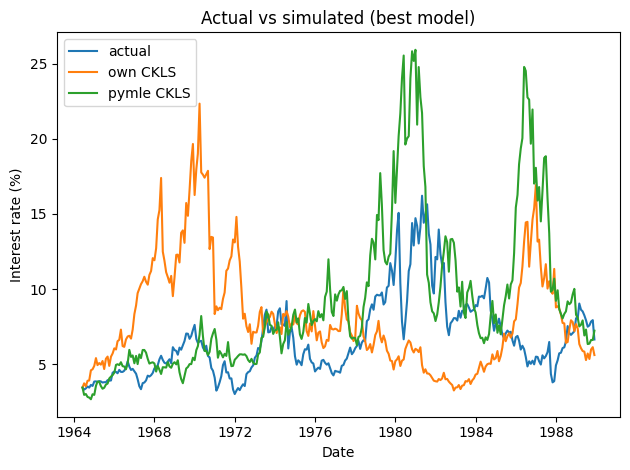

In [22]:
best=tab_df.loc[tab_df['AIC'].idxmin()]
print(f'\nBest own model: {best["Model"]} (AIC={best["AIC"]:.3f})')
bp=best[5:9].dropna().values.astype(float)
b_func,s_func,_,_,_=models[best['Model']]

X_sim=np.zeros(T)
X_sim[0]=X[0]
for i in range(1,T):
    m=em(X_sim[i-1],b_func,bp,dt)
    sig=s_func(X_sim[i-1],bp)*np.sqrt(dt)
    X_sim[i]=m+sig*np.random.randn()

plt.figure()
plt.plot(t,X,label='actual')
plt.plot(t,X_sim,label=f'own {best["Model"]}')
if pymle_df is not None:
    best2=pymle_df.loc[pymle_df['AIC'].idxmin()]
    print(f'Best pymle model: {best2["Model"]} (AIC={best2["AIC"]:.3f})')
    bp2=best2[5:9].dropna().values.astype(float)
    Mdl_class=dict(zip(pymle_names,pymle_models))[best2['Model']]
    mm=Mdl_class()
    mm.params=bp2
    X_sim2=np.zeros(T)
    X_sim2[0]=X[0]
    for i in range(1,T):
        m=X_sim2[i-1]+mm.drift(X_sim2[i-1],0)*dt
        sig=mm.diffusion(X_sim2[i-1],0)*np.sqrt(dt)
        X_sim2[i]=m+sig*np.random.randn()
    plt.plot(t,X_sim2,label=f'pymle {best2["Model"]}')

plt.legend()
plt.title('Actual vs simulated (best model)')
plt.xlabel('Date')               
plt.ylabel('Interest rate (%)')   
plt.tight_layout()
plt.show()

In [23]:
print("CKLS parameters:", res.x)


CKLS parameters: [ 2.09694865 -0.2770894   0.13358179  1.43976901]


In [24]:
print("pymle CKLS parameters:",bp2)

pymle CKLS parameters: [ 2.08159284 -0.27554783  0.13205532  1.43976453]
